Dataset shape after cleaning: (891, 6)

=== ONE-SAMPLE T-TEST (Fare vs mean=30) ===
t-statistic: 1.3240
p-value: 0.1858
Fail to reject H0

=== TWO-SAMPLE T-TEST (Age Male vs Female) ===
t-statistic: 3.0786
p-value: 0.0021
REJECT H0: Mean Age differs by Sex

=== PAIRED T-TEST (Age vs Age_filled) ===
t-statistic: nan
p-value: nan
Fail to reject H0 (imputation neutral)

=== ONE-WAY ANOVA (Fare by Pclass) ===
F-statistic: 242.3442
p-value: 0.0000
REJECT H0: Means differ across Pclass


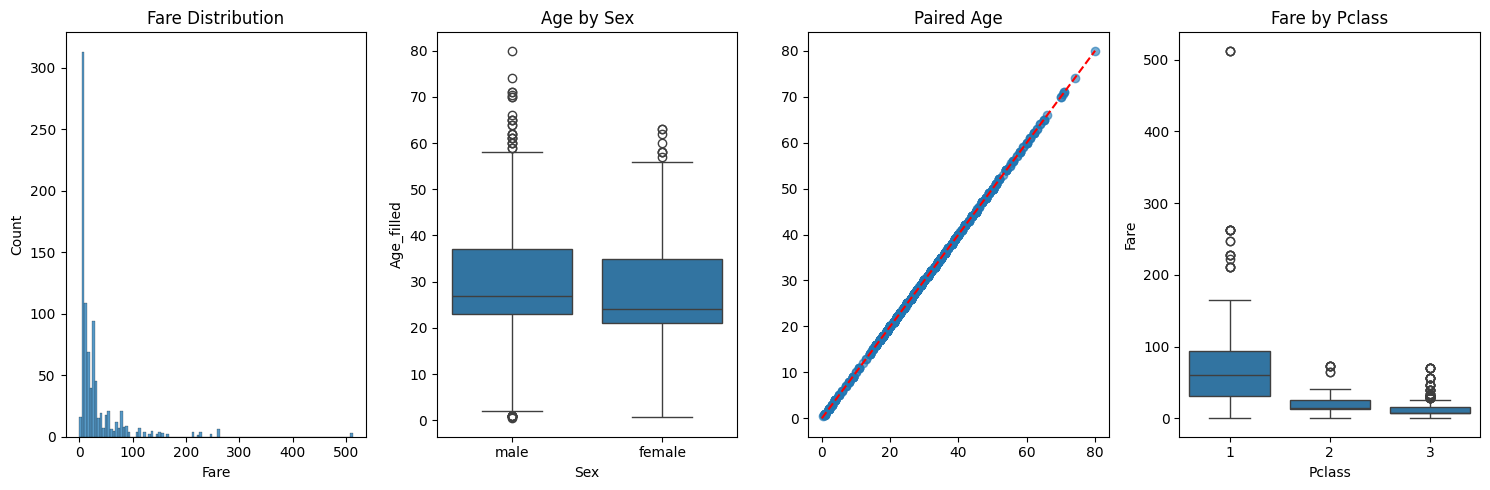

In [10]:
# Data Science Lab Assignment 4: Parametric Hypothesis Tests
# Dataset: Preprocessed Titanic (continuity from Assignments 1-3)

import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Load & preprocess (from Assignment 3)
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df['Age_filled'] = df.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
df_clean = df[['Survived', 'Pclass', 'Sex', 'Age', 'Age_filled', 'Fare']].dropna(subset=['Age_filled', 'Fare'])

print("Dataset shape after cleaning:", df_clean.shape)

# 1. ONE-SAMPLE T-TEST: Fare vs historical mean=30
fare_mean_30 = 30
t_stat1, p1 = stats.ttest_1samp(df_clean['Fare'], fare_mean_30)
print("\n=== ONE-SAMPLE T-TEST (Fare vs mean=30) ===")
print(f"t-statistic: {t_stat1:.4f}")
print(f"p-value: {p1:.4f}")
alpha = 0.05
if p1 < alpha: print("REJECT H0: Mean Fare != 30")
else: print("Fail to reject H0")

# 2. INDEPENDENT TWO-SAMPLE T-TEST: Age Male vs Female
age_male = df_clean[df_clean['Sex']=='male']['Age_filled']
age_female = df_clean[df_clean['Sex']=='female']['Age_filled']
t_stat2, p2 = stats.ttest_ind(age_male, age_female)
print("\n=== TWO-SAMPLE T-TEST (Age Male vs Female) ===")
print(f"t-statistic: {t_stat2:.4f}")
print(f"p-value: {p2:.4f}")
if p2 < alpha: print("REJECT H0: Mean Age differs by Sex")
else: print("Fail to reject H0")

# 3. PAIRED T-TEST: Age vs Age_filled (non-NaN Age)
mask = df['Age'].notna()
age_orig = df.loc[mask, 'Age'].values
age_fill = df.loc[mask, 'Age_filled'].values
t_stat3, p3 = stats.ttest_rel(age_orig, age_fill)
print("\n=== PAIRED T-TEST (Age vs Age_filled) ===")
print(f"t-statistic: {t_stat3:.4f}")
print(f"p-value: {p3:.4f}")
if p3 < alpha and not np.isnan(p3): print("REJECT H0: Mean difference !=0")
else: print("Fail to reject H0 (imputation neutral)")

# 4. ONE-WAY ANOVA: Fare by Pclass
groups = [df_clean[df_clean['Pclass']==p]['Fare'].values for p in [1,2,3]]
f_stat, p_anova = stats.f_oneway(*groups)
print("\n=== ONE-WAY ANOVA (Fare by Pclass) ===")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_anova:.4f}")
if p_anova < alpha: print("REJECT H0: Means differ across Pclass")
else: print("Fail to reject H0")

# VISUALIZATIONS (screenshot these)
plt.figure(figsize=(15, 5))

plt.subplot(1,4,1); sns.histplot(df_clean['Fare']); plt.title('Fare Distribution')
plt.subplot(1,4,2); sns.boxplot(data=df_clean, x='Sex', y='Age_filled'); plt.title('Age by Sex')
plt.subplot(1,4,3); plt.scatter(age_orig, age_fill, alpha=0.6); plt.plot([0,80],[0,80],'r--'); plt.title('Paired Age')
plt.subplot(1,4,4); sns.boxplot(data=df_clean, x='Pclass', y='Fare'); plt.title('Fare by Pclass')

plt.tight_layout()
plt.show()
